In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import dataclasses
from typing import Callable
import time

rng = np.random.default_rng(42)

In [2]:
def Bfield(x, m):
    """Dipole magnetic field, normalized to |B|=1 at the magnetic pole on the surface.
    Args:
        x : (N,3) float array -- Cartesian positions in R_star.
        m : Model             -- uses m.mhat.
    Returns:
        (N,3) float array -- B in code units.
    """
    r    = np.linalg.norm(x, axis=-1, keepdims=True)
    rhat = x / r
    mdr  = rhat @ m.mhat
    return 0.5 * (3.0 * mdr[..., None] * rhat - m.mhat) / r**3


def Bmag(x, m):
    """|B| at each position (1 at the polar surface)."""
    return np.linalg.norm(Bfield(x, m), axis=-1)


def wp2_w2(x, m):
    """(omega_p/omega)^2, GJ-like density n_e ~ |B|."""
    return m.wp2_surf * Bmag(x, m)


def wB_w(x, m):
    """omega_B/omega at each position."""
    return m.wB_surf * Bmag(x, m)


In [3]:
def H_O_isotropic(x, k, m):
    """O-mode, unmagnetized: H = 0.5(|k|^2 + wp2 - 1)."""
    return 0.5 * (np.sum(k * k, axis=1) + wp2_w2(x, m) - 1.0)


def H_O_stronglyMagnetized(x, k, m):
    """O-mode in the infinitely-magnetized cold-plasma limit (default, valid
    near the polar cap):
       n^2 = (1 - wp2)/(1 - wp2 cos^2 theta_kB)
       H = 0.5*(|k|^2 - wp2 (k.Bhat)^2 - 1 + wp2)."""
    B    = Bfield(x, m)
    Bhat = B / np.linalg.norm(B, axis=1, keepdims=True)
    kdB  = np.sum(k * Bhat, axis=1)
    wp2  = wp2_w2(x, m)
    return 0.5 * (np.sum(k * k, axis=1) - wp2 * kdB**2 - 1.0 + wp2)

In [4]:
@dataclass
class Model:
    chi: float      = np.deg2rad(30.0)
    nu_GHz: float   = 1.4              # observing/wave frequency -- FIXED for the
                                        # whole run; everything else is normalized
                                        # to it. Don't hand-edit wp2_surf/wB_surf/
                                        # omega_Rc separately to "change frequency" --
                                        # use model_from_physical() instead, which
                                        # derives all three from nu_GHz consistently.
    # EFFECTIVE relativistic (omega_p/omega)^2 at the magnetic pole, r=1:
    # wp2_eff = wp2_cold / gamma0^3 ~ 4.5e3 * kappa_3 * B12 / (P nu_GHz^2 gamma0^3).
    # kappa=1e3, B12=1, nu=1.4 GHz, P=1s, gamma0=20  ->  ~0.375.
    # NOTE: wp2_surf and gamma0 are linked through this scaling -- don't
    # change one without the other. Use model_from_physical() to keep them
    # consistent automatically.
    wp2_surf: float = 0.375
    wB_surf: float  = 2.0e9            # omega_B/omega at pole (B=1e12 G, 1.4 GHz)
    omega_Rc: float = 3.0e5            # omega R*/c at 1.4 GHz
    r_out: float    = 300.0
    H_O: Callable   = H_O_stronglyMagnetized
    # --- O<->X conversion: Landau-Zener, this is the only model ---
    alpha_conv: float = 0.6            # alpha in eta = sqrt(2) p (1-p)^alpha
    gamma0: float      = 20.0          # flow Lorentz factor -- must match wp2_surf!
    beta0: float       = None
    # --- polarization freezing ---
    freeze_on: bool = True
    r_freeze: float = 150.0

    def __post_init__(self):
        if self.beta0 is None:
            self.beta0 = np.sqrt(1.0 - 1.0 / self.gamma0**2)
        assert self.r_freeze < self.r_out, "r_freeze must lie inside r_out"

    @property
    def mhat(self):
        return np.array([np.sin(self.chi), 0.0, np.cos(self.chi)])


def model_from_physical(nu_GHz=1.4, B12=1.0, P=1.0, kappa_3=1.0, gamma0=20.0,
                         chi_deg=30.0, R_km=10.0, coeff_wp2=5598.5, **kwargs):
    """Build a Model from physical neutron-star/pulsar parameters at a single
    FIXED observing frequency, so that wp2_surf, wB_surf, and omega_Rc are
    always mutually consistent (change nu_GHz, B12, P, kappa_3, or gamma0
    here -- never hand-edit the derived Model fields separately).

    RECOMMENDED BASE CASE (canonical NS, propagating at L-band):
        model_from_physical(nu_GHz=1.4, B12=1.0, P=1.0, kappa_3=1.0, gamma0=20.0)
    See the derivation below for why gamma0~20 (not 10) is the number that
    makes this self-consistent, rather than an arbitrary pick.

    Scalings used (all at the pole, r=1; the r-DEPENDENCE away from the pole
    is separate and already handled by wp2_w2()/wB_w(), which multiply these
    surface values by Bmag(x,m) ~ 1/r^3 -- see those functions):
        omega_B/omega   = nu_B(B12) / nu_GHz,  nu_B[GHz] = 2.8e9 * B12
                          (electron cyclotron frequency, 2.8 MHz per Gauss)
        omega*R_star/c  = 2*pi * nu_GHz[Hz] * R_star[cm] / c
        (omega_p/omega)^2_eff = coeff_wp2 * kappa_3 * B12 / (P * nu_GHz^2 * gamma0^3)
                          (relativistically suppressed by the streaming
                          Lorentz factor gamma0)

    coeff_wp2 default (5598.5) is derived from first principles, not fit to
    match the original notebook's ambiguous comment:
        n_GJ = B/(P*c*e)                         (Goldreich-Julian density)
        omega_p^2 = 4*pi*(kappa*n_GJ)*e^2/m_e     (kappa = kappa_3*1e3)
        wp2_surf  = omega_p^2 / (gamma0^3 * omega_obs^2)
    which gives n_GJ~7e10 cm^-3 for B12=P=1 (matches the textbook value) and
    an UNSUPPRESSED plasma frequency ~75 GHz at kappa_3=B12=P=1 -- radio
    waves can only escape at all because gamma0^{3/2} suppression brings this
    down near the observing band.

    WHY gamma0~20, not the "conservative" 10, is the right call for a 1.4 GHz
    base case: solving wp2_surf(gamma0) = 0.375 (a comfortably-propagating,
    not marginal, value) at nu_GHz=1.4 and kappa_3=B12=P=1 gives gamma0=19.7.
    At gamma0=10, the same canonical parameters give wp2_surf~2.9 (ABOVE 1,
    i.e. below the local plasma cutoff at the surface -- not a "more
    conservative" version of the same regime, but a qualitatively different,
    non-propagating one). If you want gamma0=10 specifically, you need to
    lower kappa_3 and/or B12 to compensate -- gamma0 is not a free knob to
    lower in isolation without touching the other three.

    Args:
        nu_GHz    : observing/wave frequency in GHz. Typical radio pulsar
                    band is roughly 0.1-3 GHz; this is ONE fixed value per run.
        B12       : polar surface magnetic field, in units of 1e12 G.
        P         : spin period in seconds.
        kappa_3   : pair multiplicity above Goldreich-Julian, in units of 1e3.
        gamma0    : bulk Lorentz factor of the streaming pair plasma.
        chi_deg   : magnetic obliquity in degrees.
        R_km      : stellar radius in km (default 10).
        coeff_wp2 : coefficient in the wp2_eff scaling relation above; the
                    default is the first-principles GJ value, override only
                    if your own derivation uses a different convention
                    (e.g. counting e+/e- separately).
        **kwargs  : forwarded to Model (e.g. r_out, alpha_conv, freeze_on,
                    r_freeze, H_O).
    Returns:
        Model instance with wp2_surf, wB_surf, omega_Rc, gamma0, nu_GHz, chi set.
    """
    nu_B_GHz = 2.8e9 * B12
    wB_surf  = nu_B_GHz / nu_GHz
    R_cm, c_cm = R_km * 1e5, 3.0e10
    omega_Rc = 2*np.pi * (nu_GHz * 1e9) * R_cm / c_cm
    wp2_surf = coeff_wp2 * kappa_3 * B12 / (P * nu_GHz**2 * gamma0**3)
    return Model(chi=np.deg2rad(chi_deg), nu_GHz=nu_GHz, wp2_surf=wp2_surf,
                 wB_surf=wB_surf, omega_Rc=omega_Rc, gamma0=gamma0, **kwargs)


M = model_from_physical()   # the recommended base case, see docstring above

In [5]:
def wres_w(x, m):
    """omega_res/omega = sqrt(wp2_eff) / (1 - beta0).
    (wp2_w2 already returns the gamma-suppressed value, and the gamma factors
    from omega_res,cold cancel against gamma0^{3/2} -- see derivation in the
    Model docstring.)
    """
    return np.sqrt(wp2_w2(x, m)) / (1.0 - m.beta0)


def eps_param(x, m):
    """eps = omega/omega_res."""
    return 1.0 / wres_w(x, m)


def curvature_radius(x, m, rel_eps=1e-4):
    """Field-line curvature radius rho = 1/|dBhat/ds|, in R_star."""
    B    = Bfield(x, m)
    Bhat = B / np.linalg.norm(B, axis=1, keepdims=True)
    eps  = rel_eps * np.linalg.norm(x, axis=1, keepdims=True)
    Bp   = Bfield(x + eps * Bhat, m); Bp /= np.linalg.norm(Bp, axis=1, keepdims=True)
    Bm   = Bfield(x - eps * Bhat, m); Bm /= np.linalg.norm(Bm, axis=1, keepdims=True)
    kap  = np.linalg.norm(Bp - Bm, axis=1) / (2.0 * eps[:, 0])
    return 1.0 / np.maximum(kap, 1e-30)


def conversion_frame(x_ref, m, rel_eps=1e-4):
    """Fixed per-ray frame at the reference point: z0 || B, x0 along dBhat/ds
    (osculating plane, perp to z0), y0 = z0 x x0.
    Returns:
        (x0hat, y0hat, z0hat) : three (N,3) float arrays.
    """
    B   = Bfield(x_ref, m)
    z0  = B / np.linalg.norm(B, axis=1, keepdims=True)
    eps = rel_eps * np.linalg.norm(x_ref, axis=1, keepdims=True)
    Bp  = Bfield(x_ref + eps * z0, m); Bp /= np.linalg.norm(Bp, axis=1, keepdims=True)
    Bm  = Bfield(x_ref - eps * z0, m); Bm /= np.linalg.norm(Bm, axis=1, keepdims=True)
    c   = (Bp - Bm) / (2.0 * eps)
    c  -= np.sum(c * z0, axis=1, keepdims=True) * z0
    cn  = np.linalg.norm(c, axis=1, keepdims=True)
    bad = (cn[:, 0] < 1e-12)                       # straight field line (on-axis)
    if bad.any():
        alt = np.cross(z0[bad], [0.0, 0.0, 1.0])
        degen = np.linalg.norm(alt, axis=1) < 1e-8
        alt[degen] = [1.0, 0.0, 0.0]
        c[bad]  = alt
        cn[bad] = np.linalg.norm(alt, axis=1, keepdims=True)
    x0 = c / cn
    y0 = np.cross(z0, x0)
    return x0, y0, z0


def delta_LZ(x, k, x0hat, y0hat, m):
    """Delta = 2 ktx^3 rho_t sin^3(phi) / (3|eps^2 - 1|), all evaluated
    LOCALLY at (x, k) using a frame (x0hat, y0hat) established AT x itself
    (the local field-line curvature frame, recomputed every time this is
    called -- not held fixed across a passage).
    """
    ktx   = np.abs(np.sum(k * x0hat, axis=1))
    rho_t = m.omega_Rc * curvature_radius(x, m)
    B     = Bfield(x, m)
    Bx    = np.sum(B * x0hat, axis=1)
    By    = np.sum(B * y0hat, axis=1)
    sinph = np.abs(By) / np.maximum(np.sqrt(Bx**2 + By**2), 1e-30)
    eps   = eps_param(x, m)
    denom = 3.0 * np.maximum(np.abs(eps**2 - 1.0), 1e-12)
    return 2.0 * ktx**3 * rho_t * sinph**3 / denom


def eta_LZ(delta, m):
    """eta = sqrt(2) p (1-p)^alpha, p = exp(-Delta). This IS the full formula
    -- no extra efficiency prefactor. Clipped to [0,1] for float safety only.
    """
    p = np.exp(-delta)
    return np.clip(np.sqrt(2.0) * p * (1.0 - p) ** m.alpha_conv, 0.0, 1.0)



In [6]:
def gradH_x(x, k, m, rel_eps=1e-4):
    """dH/dx at fixed k, central differences."""
    g   = np.empty_like(x)
    eps = rel_eps * np.linalg.norm(x, axis=1)
    for i in range(3):
        dx = np.zeros_like(x); dx[:, i] = eps
        g[:, i] = (m.H_O(x + dx, k, m) - m.H_O(x - dx, k, m)) / (2.0 * eps)
    return g


def gradH_k(x, k, m, eps=1e-6):
    """dH/dk at fixed x (group-velocity direction), central differences."""
    g = np.empty_like(k)
    for i in range(3):
        dk = np.zeros_like(k); dk[:, i] = eps
        g[:, i] = (m.H_O(x, k + dk, m) - m.H_O(x, k - dk, m)) / (2.0 * eps)
    return g


def rhs(x, k, isO, m):
    """dx/ds = (dH/dk)/|dH/dk|, dk/ds = -(dH/dx)/|dH/dk|; X-modes go straight."""
    dx = np.zeros_like(k)
    dk = np.zeros_like(k)
    dx[~isO] = k[~isO]
    if isO.any():
        xo, ko = x[isO], k[isO]
        vg = gradH_k(xo, ko, m)
        vn = np.linalg.norm(vg, axis=1, keepdims=True)
        dx[isO] =  vg / vn
        dk[isO] = -gradH_x(xo, ko, m) / vn
    return dx, dk


def rk4_step(x, k, isO, h, m):
    """One RK4 step of the ray equations, per-ray step size h."""
    h1 = h[:, None]
    a1x, a1k = rhs(x,            k,             isO, m)
    a2x, a2k = rhs(x+0.5*h1*a1x, k+0.5*h1*a1k,  isO, m)
    a3x, a3k = rhs(x+0.5*h1*a2x, k+0.5*h1*a2k,  isO, m)
    a4x, a4k = rhs(x+h1*a3x,     k+h1*a3k,      isO, m)
    xn = x + h1/6.0 * (a1x + 2*a2x + 2*a3x + a4x)
    kn = k + h1/6.0 * (a1k + 2*a2k + 2*a3k + a4k)
    return xn, kn


def solve_n(x, khat, m, n_lo=1e-6, n_hi=1.0 + 1e-6, iters=48):
    """Solve H(x, n*khat) = 0 for n on the escaping (n<=1) branch.
    Returns:
        (n, ok) : (N,) float array (<=1), (N,) bool (ok=False -> evanescent).
    """
    f_lo = m.H_O(x, n_lo * khat, m)
    f_hi = m.H_O(x, n_hi * khat, m)
    ok   = (f_lo * f_hi) < 0.0
    lo   = np.full(len(x), n_lo); hi = np.full(len(x), n_hi)
    for _ in range(iters):
        mid  = 0.5 * (lo + hi)
        f_md = m.H_O(x, mid[:, None] * khat, m)
        up   = (f_md * f_lo) > 0.0
        lo   = np.where(up, mid, lo); f_lo = np.where(up, f_md, f_lo)
        hi   = np.where(up, hi, mid)
    return np.minimum(0.5 * (lo + hi), 1.0), ok


In [7]:
def propagate(x, k, isO, m, t_emit=None, h_frac=0.02, max_steps=50000,
              apply_conversion=True, progress=True):
    """Integrate rays to escape (r>r_out) or absorption (r<1).
    Args:
        x, k     : (N,3) initial positions [R*] and wavevectors [omega/c].
        isO      : (N,) bool, True = O mode.
        m        : Model.
        t_emit   : (N,) initial path length / time offset (default zeros).
        h_frac   : step size as fraction of local radius. Reduce this (and
                   check `convergence_test`) if nconv / final O-fraction
                   still drift when you halve it.
        max_steps: safety cap.
        apply_conversion : if True (default), a mode flip is drawn and
                   applied each step, feeding back into subsequent refraction
                   (the physical run). If False, mode is held fixed for the
                   whole flight and no flips happen -- `nconv_exp` (see below)
                   is still accumulated, giving a DETERMINISTIC diagnostic
                   (no RNG draws at all) of whether the rate integral itself
                   is converging, decoupled from realized-count shot noise
                   and from conversion feeding back into the trajectory. Use
                   this for convergence checks; use the default for physics.
        progress : print a lightweight one-line status update (throttled to ~2/sec), no external dependency.
    Returns:
        dict: x, k, isO, Bfrz, t, escaped, hit, lost, nconv, nconv_exp, frozen.
        nconv_exp is the running sum of per-step probabilities eta/rho*ds
        (the expected conversion count along the ORIGINAL, as-launched mode
        trajectory) -- computed every run regardless of apply_conversion.
    """
    N      = len(x)
    x, k   = x.copy(), k.copy()
    isO    = isO.copy()
    active = np.ones(N, bool)
    hit    = np.zeros(N, bool)
    lost   = np.zeros(N, bool)
    frozen = np.zeros(N, bool)
    nconv     = np.zeros(N, int)
    nconv_exp = np.zeros(N, float)
    s      = np.zeros(N) if t_emit is None else np.asarray(t_emit, float).copy()
    Bfrz   = Bfield(x, m)

    def _norm(v):
        return np.linalg.norm(v, axis=1)

    def _unit(v):
        return v / np.linalg.norm(v, axis=1, keepdims=True)

    def _apply_flips(flip):
        """Swap mode of rays `flip` at their current position; k direction kept."""
        if flip.size == 0:
            return
        newO  = ~isO[flip]
        kh    = _unit(k[flip])
        n_new = np.ones(flip.size)
        ok    = np.ones(flip.size, bool)
        if newO.any():                                # X -> O needs a real O root
            n_O, ok_O   = solve_n(x[flip][newO], kh[newO], m)
            n_new[newO] = n_O
            ok[newO]    = ok_O
        flip, kh, n_new = flip[ok], kh[ok], n_new[ok]
        if flip.size:
            isO[flip]    = ~isO[flip]
            k[flip]      = kh * n_new[:, None]
            nconv[flip] += 1

    t_start = time.time()
    t_last  = t_start
    for step in range(max_steps):
        idx = np.where(active)[0]
        if idx.size == 0:
            break
        # ---------------- one RK4 step -----------------------------------------
        x_old, k_old = x[idx].copy(), k[idx].copy()
        h = h_frac * _norm(x_old)
        x_new, k_new = rk4_step(x_old, k_old, isO[idx], h, m)
        x[idx], k[idx] = x_new, k_new
        s[idx] += h
        # ---------------- termination bookkeeping -----------------------------
        finite = np.isfinite(x_new).all(1) & np.isfinite(k_new).all(1)
        r_new  = np.where(finite, _norm(np.nan_to_num(x_new)), np.nan)
        esc    = finite & (r_new > m.r_out)
        crash  = finite & (r_new < 1.0)
        bad    = ~finite
        done   = esc | crash | bad
        active[idx[done]] = False
        hit[idx[crash]]   = True
        lost[idx[bad]]    = True
        if progress:
            now = time.time()
            if now - t_last > 0.5:                  # throttle to ~2 updates/sec
                t_last = now
                print(f"\rstep {step+1}/{max_steps}  active={int(active.sum())}/{N}  "
                      f"conv={int(nconv.sum())}  elapsed={now-t_start:.1f}s",
                      end="", flush=True)
        keep = ~done
        al   = idx[keep]
        if al.size == 0:
            continue
        r_al = r_new[keep]
        h_al = h[keep]
        # ---------------- polarization freezing -------------------------------
        if m.freeze_on:
            frozen[al[r_al > m.r_freeze]] = True
        cm  = ~frozen[al]
        upd = al[cm]
        if upd.size == 0:
            continue
        Bfrz[upd] = Bfield(x[upd], m)            # PA reference tracks B while coupled
        # ---------------- mode conversion (Landau-Zener, local rate) ----------
        # Delta/eta are smooth local quantities (no crossing/event to detect).
        # The coherence length for one passage is NOT rho itself -- rho is
        # just the field-line curvature scale from theta=xi/rho. The coupling
        # is significant over xi ~ tilde_k_x * rho (where delta_x ~ tilde_k_x/eps
        # in the passage expansion), confirmed numerically: a traced near-peak
        # window had width ~1.2 with rho~9.2 there but tilde_k_x*rho~0.36 --
        # same order of magnitude as the real width, whereas rho alone
        # overestimates the coherence length (and thus underestimates the
        # rate) by about 8x for that example. tilde_k_x*rho is the local
        # RATE length scale; eta/(tilde_k_x*rho) is the local conversion rate.
        x0u, y0u, _ = conversion_frame(x[upd], m)      # frame local to THIS point
        delta = delta_LZ(x[upd], k[upd], x0u, y0u, m)
        eta   = eta_LZ(delta, m)
        rho   = curvature_radius(x[upd], m)
        ktx   = np.abs(np.sum(k[upd] * x0u, axis=1))
        l_coh = np.maximum(ktx, 1e-6) * rho
        lam   = eta / np.maximum(l_coh, 1e-30)
        P     = -np.expm1(-lam * h_al[cm])
        nconv_exp[upd] += P                     # deterministic, no RNG
        if apply_conversion:
            flip = upd[rng.random(upd.size) < P]
            _apply_flips(flip)
    if progress:
        print(f"\rstep {step+1}/{max_steps}  active={int(active.sum())}/{N}  "
              f"conv={int(nconv.sum())}  elapsed={time.time()-t_start:.1f}s")
    n_stuck = int(active.sum())
    if n_stuck:
        print(f"WARNING: {n_stuck} rays still active after {max_steps} steps "
              f"(increase max_steps or check h_frac/r_out).")
    if lost.any():
        print(f"WARNING: {int(lost.sum())} rays produced non-finite state "
              f"and were dropped.")

    escaped = ~active & ~hit & ~lost
    return dict(x=x, k=k, isO=isO, Bfrz=Bfrz, t=s, escaped=escaped, hit=hit,
                lost=lost, nconv=nconv, nconv_exp=nconv_exp, frozen=frozen)



In [8]:
def convergence_test(x0, k0, isO0, m, h_fracs=(0.04, 0.02, 0.01, 0.005),
                      max_steps=6000, progress=False):
    """Check step-size convergence using the DETERMINISTIC expected-conversion
    accumulator (`nconv_exp`, apply_conversion=False) -- no RNG draws, no mode
    feedback into the trajectory, so this isolates whether the integral
    integral(eta/rho ds) itself is converging as h_frac shrinks, free of the
    shot noise that swamps the realized (stochastic) conversion count at
    modest N. This is the number to check, not the realized `nconv` from a
    physics run -- that one is expected to look noisy even when the
    underlying rate integral is fully converged (see nconv_exp vs nconv here).
    Args:
        x0, k0, isO0 : launch state (same for every h_frac).
        m            : Model.
        h_fracs      : sequence of step sizes to test, largest first.
        max_steps    : passed through to propagate (increase if smaller
                       h_frac needs more steps to reach r_out).
        progress     : print status lines during each propagate() call.
    Returns:
        list of dicts with keys h_frac, mean_nconv_exp.
    """
    rows = []
    for hf in h_fracs:
        r = propagate(x0.copy(), k0.copy(), isO0.copy(), m,
                      h_frac=hf, max_steps=max_steps,
                      apply_conversion=False, progress=progress)
        rows.append(dict(h_frac=hf, mean_nconv_exp=r['nconv_exp'].mean()))
        print(f"h_frac={hf:<7g}  <nconv_exp>={rows[-1]['mean_nconv_exp']:.6f}")
    return rows

In [9]:
def rotate_z_to(vecs, axis):
    """Rotate vectors so the z-axis maps onto `axis` (unit vector)."""
    z = np.array([0.0, 0.0, 1.0])
    c = float(np.dot(z, axis))
    if c > 1.0 - 1e-12:
        return vecs.copy()
    if c < -1.0 + 1e-12:
        return vecs * np.array([1.0, -1.0, -1.0])
    v = np.cross(z, axis)
    sn = np.linalg.norm(v)
    vx = np.array([[0, -v[2], v[1]],
                   [v[2], 0, -v[0]],
                   [-v[1], v[0], 0]])
    R = np.eye(3) + vx + vx @ vx * ((1.0 - c) / sn**2)
    return vecs @ R.T


def polar_cap_dirs(N, m, deg=10.0, rng=rng):
    """Unit vectors over two antipodal caps of half-angle `deg` around m.mhat."""
    c   = np.cos(np.deg2rad(deg))
    n_n = N // 2
    n_s = N - n_n
    u   = np.concatenate([rng.uniform(c, 1.0, n_n),
                          rng.uniform(-1.0, -c, n_s)])
    ph  = rng.uniform(0, 2*np.pi, N)
    s   = np.sqrt(1.0 - u**2)
    d   = np.stack([s*np.cos(ph), s*np.sin(ph), u], axis=1)
    return rotate_z_to(d, m.mhat)


def launch_polar_cap(N, m, r_em=1.05, f_O=1.0, cap_deg=10.0, t_emit=None):
    """Radially outgoing rays from two antipodal polar caps, prescribed O/X mix."""
    rhat = polar_cap_dirs(N, m, deg=cap_deg, rng=rng)
    x    = r_em * rhat
    isO  = rng.random(N) < f_O
    n    = np.ones(N)
    good = np.ones(N, bool)
    if isO.any():
        n_O, ok_O = solve_n(x[isO], rhat[isO], m)
        n[isO]    = n_O
        good[isO] = ok_O
    k  = rhat * n[:, None]
    te = np.zeros(N) if t_emit is None else np.asarray(t_emit, float)
    dropped = N - int(good.sum())
    if dropped:
        print(f"launch_polar_cap: dropped {dropped}/{N} evanescent O-mode rays "
              f"({100*dropped/N:.1f}%).")
    return x[good], k[good], isO[good], te[good]


def launch_radial(N, m, r_em=1.05, f_O=1.0, t_emit=None):
    """Isotropic shell of radially outgoing rays, prescribed O/X mix."""
    u    = rng.uniform(-1, 1, N)
    ph   = rng.uniform(0, 2*np.pi, N)
    s    = np.sqrt(1 - u**2)
    rhat = np.stack([s*np.cos(ph), s*np.sin(ph), u], axis=1)
    x    = r_em * rhat
    isO  = rng.random(N) < f_O
    n    = np.ones(N)
    good = np.ones(N, dtype=bool)
    if isO.any():
        n_O, ok_O = solve_n(x[isO], rhat[isO], m)
        n[isO]    = n_O
        good[isO] = ok_O
    k  = rhat * n[:, None]
    te = np.zeros(N) if t_emit is None else np.asarray(t_emit, float)
    return x[good], k[good], isO[good], te[good]


def launch_field_aligned(N, m, r_em=1.05, f_O=0.5, cap_deg=10.0, t_emit=None,
                          rng=rng):
    """Rays launched exactly TANGENT to the local dipole field line at each
    emission point (a discharge streaming along B) -- NOT radially outward,
    and with no additional angular spread: k_hat = Bhat(x_em) exactly.

    tilde_k_x is therefore exactly 0 at emission for every ray; it becomes
    nonzero purely through subsequent O-mode refraction along the ray
    (visible directly in the propagated trajectory), not from anything set
    at launch.

    cap_deg is just where on the star the discharge footpoints are drawn
    from (colatitude spread around the magnetic axis) -- it can be any
    size; there is no polar-cap/open-field-line restriction imposed here,
    and no expectation of rays terminating at r<1 because of it.

    Args:
        N       : int -- rays to draw (returned M<=N after evanescence cut).
        m       : Model -- uses m.mhat, m.H_O.
        r_em    : float -- emission radius in R_star.
        f_O     : float -- fraction launched as O-mode (rest X).
        cap_deg : float -- footpoint half-angle (deg) around the magnetic axis.
        t_emit  : (N,) float array or None -- emission times (default zeros).
        rng     : numpy Generator.
    Returns:
        (x, k, isO, t_emit) : (M,3), (M,3), (M,), (M,).
    """
    # --- footpoints on the polar cap (same scheme as launch_polar_cap) ---
    rhat_foot = polar_cap_dirs(N, m, deg=cap_deg, rng=rng)
    x = r_em * rhat_foot

    # --- local field direction at each footpoint: this is the launch
    #     direction exactly. Bfield() alternates sign by hemisphere (dipole
    #     lines enter at one pole, leave at the other) -- flip it to always
    #     point outward (away from the star), the physical streaming
    #     direction, regardless of which magnetic pole the footpoint is near. ---
    khat = Bfield(x, m)
    khat = khat / np.linalg.norm(khat, axis=1, keepdims=True)
    inward = np.sum(khat * rhat_foot, axis=1) < 0.0
    khat[inward] *= -1.0

    isO  = rng.random(N) < f_O
    n    = np.ones(N)
    good = np.ones(N, bool)
    if isO.any():
        n_O, ok_O = solve_n(x[isO], khat[isO], m)
        n[isO]    = n_O
        good[isO] = ok_O
    k  = khat * n[:, None]
    te = np.zeros(N) if t_emit is None else np.asarray(t_emit, float)
    dropped = N - int(good.sum())
    if dropped:
        print(f"launch_field_aligned: dropped {dropped}/{N} evanescent O-mode rays "
              f"({100*dropped/N:.1f}%).")
    return x[good], k[good], isO[good], te[good]

In [10]:
def launch_polar_cap_binned(n_per_bin, m, colat_edges_deg, r_em=1.05, f_O=0.5,
                             rng=rng):
    """Launch mixed O/X rays in colatitude annuli around the magnetic axis.
    Args:
        n_per_bin      : int -- rays drawn per colatitude bin (before evanescence cut).
        m              : Model.
        colat_edges_deg: 1D array of bin edges in degrees from the magnetic axis
                         (e.g. [0,5,10,...]); north+south caps both populated.
        r_em           : float -- emission radius in R_star.
        f_O            : float -- fraction launched as O-mode (rest X).
        rng            : numpy Generator.
    Returns:
        (x, k, isO, bin_idx, edges) : (M,3),(M,3),(M,) bool,(M,) int, edges array.
    """
    edges = np.asarray(colat_edges_deg, float)
    xs, ks, isOs, bins_ = [], [], [], []
    for i in range(len(edges) - 1):
        c_lo, c_hi = edges[i], edges[i + 1]
        N = n_per_bin
        u_lo, u_hi = np.cos(np.deg2rad(c_hi)), np.cos(np.deg2rad(c_lo))
        n_n = N // 2; n_s = N - n_n
        u  = np.concatenate([rng.uniform(u_lo, u_hi, n_n),
                             rng.uniform(-u_hi, -u_lo, n_s)])
        ph = rng.uniform(0, 2*np.pi, N)
        s  = np.sqrt(np.clip(1.0 - u**2, 0.0, None))
        d  = np.stack([s*np.cos(ph), s*np.sin(ph), u], axis=1)
        rhat = rotate_z_to(d, m.mhat)
        x    = r_em * rhat
        isO  = rng.random(N) < f_O
        n    = np.ones(N); good = np.ones(N, bool)
        if isO.any():
            n_O, ok_O = solve_n(x[isO], rhat[isO], m)
            n[isO]    = n_O
            good[isO] = ok_O
        k = rhat * n[:, None]
        xs.append(x[good]); ks.append(k[good]); isOs.append(isO[good])
        bins_.append(np.full(int(good.sum()), i))
    return (np.concatenate(xs), np.concatenate(ks), np.concatenate(isOs),
            np.concatenate(bins_), edges)


def geometry_sweep(m, n_per_bin=3000, colat_edges_deg=None, f_O=0.5,
                    h_frac=0.01, max_steps=4000, progress=False):
    """Run the mixed O/X ensemble across colatitude bins and report the
    outgoing (escaped) mode fractions per bin.
    Args:
        m               : Model (frequency is fixed by m's parameters).
        n_per_bin       : rays drawn per bin (before evanescence cut).
        colat_edges_deg : bin edges in degrees; default 0-35 in 5-deg steps.
        f_O             : launched O-mode fraction.
        h_frac, max_steps, progress : passed to propagate().
    Returns:
        (rows, res, bin_idx) : rows is a list of per-bin dicts; res/bin_idx
        are the raw propagate() output and per-ray bin index, for further analysis.
    """
    if colat_edges_deg is None:
        colat_edges_deg = np.linspace(0, 35, 8)
    x, k, isO, bin_idx, edges = launch_polar_cap_binned(
        n_per_bin, m, colat_edges_deg, f_O=f_O)
    res = propagate(x, k, isO, m, h_frac=h_frac, max_steps=max_steps,
                     progress=progress)
    rows = []
    for i in range(len(edges) - 1):
        sel = (bin_idx == i) & res['escaped']
        n_tot = int(sel.sum())
        if n_tot == 0:
            rows.append(dict(colat_lo=edges[i], colat_hi=edges[i+1], n_escaped=0,
                              f_O_out=np.nan, f_X_out=np.nan, mean_nconv=np.nan))
            continue
        f_O_out = float(res['isO'][sel].mean())
        rows.append(dict(colat_lo=edges[i], colat_hi=edges[i+1], n_escaped=n_tot,
                          f_O_out=f_O_out, f_X_out=1.0 - f_O_out,
                          mean_nconv=float(res['nconv'][bin_idx == i].mean())))
    return rows, res, bin_idx



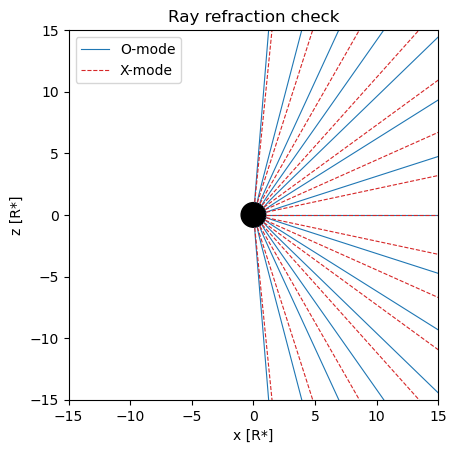

In [11]:
def trace_paths(x0, k0, isO, m, h_frac=0.01, max_steps=3000):
    """Integrate rays while storing the full trajectory (no conversion/freezing)."""
    x, k = x0.copy(), k0.copy()
    path = [x.copy()]
    for _ in range(max_steps):
        r = np.linalg.norm(x, axis=1)
        if (r > m.r_out).all():
            break
        x, k = rk4_step(x, k, isO, h_frac*np.clip(r, None, m.r_out), m)
        path.append(x.copy())
    return np.array(path)


if __name__ == "__main__":
    Mdemo = Model(chi=0.0, wp2_surf=0.9)
    th = np.linspace(0.1, np.pi-0.1, 15)
    rhat = np.stack([np.sin(th), 0*th, np.cos(th)], axis=1)
    x0 = 1.05 * rhat
    for mode, style, lab in [(True, 'C0-', 'O-mode'), (False, 'C3--', 'X-mode')]:
        isO = np.full(len(x0), mode)
        n0  = np.where(isO, np.sqrt(np.clip(1 - wp2_w2(x0, Mdemo), 0, None)), 1.0)
        P   = trace_paths(x0, rhat*n0[:, None], isO, Mdemo)
        plt.plot(P[:, :, 0], P[:, :, 2], style, lw=0.8,
                 label=[lab]+[None]*(len(x0)-1))
    plt.gca().add_patch(plt.Circle((0, 0), 1, color='k'))
    plt.xlim(-15, 15); plt.ylim(-15, 15); plt.gca().set_aspect(1)
    plt.legend(); plt.xlabel('x [R*]'); plt.ylabel('z [R*]')
    plt.title('Ray refraction check')
    plt.show()

In [12]:
# M = Model()
# Mtest = dataclasses.replace(M, r_out=30.0, r_freeze=15.0)
# x0, k0, isO0, te = launch_field_aligned(150, Mtest, r_em=1.1, f_O=1.0, cap_deg=35.0)
# convergence_test(x0, k0, isO0, Mtest, h_fracs=(0.05, 0.01, 0.002, 0.001))

In [ ]:
N = 1000000
x0, k0, isO0, te = launch_field_aligned(N, M, r_em=1.5, f_O=0.9, cap_deg=20.0)
res = propagate(x0, k0, isO0, M, t_emit=te, h_frac=0.002)
print(f"escaped: {res['escaped'].sum()}, hit star: {res['hit'].sum()}, "
      f"mean conversions/ray: {res['nconv'].mean():.3f}, "
      f"final O fraction: {res['isO'][res['escaped']].mean():.3f}")

step 6/50000  active=1000000/1000000  conv=23074  elapsed=92.1s

In [ ]:
def save_dict_to_hdf5(dictionary, filename):
    filename = pathlib.Path(filename)
    with h5py.File(filename, "w", libver="latest") as h5f:
        for name, data in dictionary.items():
            arr = np.asarray(data)
            # Choose a modest chunk size – 1 MiB is a good rule of thumb.
            chunks = (min(arr.shape[0], max(1, int(1e6 // arr.itemsize))),) if arr.ndim == 1 else None

            h5f.create_dataset(
                name,
                data=arr,
                compression="gzip",
                compression_opts=4,
                chunks=chunks,
                shuffle=True,
            )
    print(f"✅  Saved {len(dictionary)} datasets to {filename}")


def load_dict_from_hdf5(filename):
    out = {}
    with h5py.File(filename, "r") as h5f:
        for name in h5f.keys():
            out[name] = h5f[name][...]   # read fully into memory
    return out


In [ ]:
save_dict_to_hdf5(res, "res_out.h5")

In [52]:
def make_maps(res, nph=360, nth=180):
    """Bin escaped rays onto a (phase/azimuth, cos-theta) sky grid and accumulate Stokes I, Q, U and X-mode fraction, with PA set by projected B at the freeze point (O parallel, X perpendicular).

    Args:
        res : dict -- output dictionary of propagate() (uses keys x, k, isO, Bfrz, escaped).
        nph : int  -- number of azimuthal (rotation phase) bins (default 120).
        nth : int  -- number of cos(theta) (line-of-sight colatitude) bins (default 60).

    Returns:
        dict with keys:
            I, Q, U : (nth, nph) binned Stokes maps,
            Xf      : (nth, nph) binned X-mode photon counts,
            phie    : (nph+1,) azimuth bin edges [rad],
            cthe    : (nth+1,) cos(theta) bin edges.
    """
    sel  = res['escaped']
    k    = res['k'][sel]; isO = res['isO'][sel]; B = res['Bfrz'][sel]
    khat = k / np.linalg.norm(k, axis=1, keepdims=True)
    cth  = khat[:, 2]
    phi  = np.mod(np.arctan2(khat[:, 1], khat[:, 0]), 2*np.pi)

    # sky basis perpendicular to khat (reference: celestial north = z)
    zax = np.array([0.0, 0.0, 1.0])
    e1  = np.cross(np.broadcast_to(zax, khat.shape), khat)
    bad = np.linalg.norm(e1, axis=1) < 1e-8
    e1[bad] = np.cross([1.0, 0, 0], khat[bad])
    e1 /= np.linalg.norm(e1, axis=1, keepdims=True)
    e2  = np.cross(khat, e1)

    psiB = np.arctan2(np.sum(B*e2, axis=1), np.sum(B*e1, axis=1))
    psi  = np.where(isO, psiB, psiB + np.pi/2)     # O || B_proj, X perp
    Q, U = np.cos(2*psi), np.sin(2*psi)

    bins = [np.linspace(0, 2*np.pi, nph+1), np.linspace(-1, 1, nth+1)]
    H  = lambda w: np.histogram2d(phi, cth, bins=bins, weights=w)[0].T
    I  = H(np.ones(len(phi)))
    return dict(I=I, Q=H(Q), U=H(U), Xf=H((~isO).astype(float)),
                phie=bins[0], cthe=bins[1])

def plot_maps(mp):
    """Plot the four all-sky maps (intensity, linear polarization fraction, polarization angle, X-mode fraction) from a make_maps() output.

    Args:
        mp : dict -- output dictionary of make_maps() (uses keys I, Q, U, Xf).

    Returns:
        (L, PA, Xf) : (nth, nph) arrays -- linear pol. fraction L/I, polarization angle [deg], and X-mode fraction, for further use.
    """
    I = mp['I'].copy(); I[I == 0] = np.nan
    L  = np.sqrt(mp['Q']**2 + mp['U']**2) / I
    PA = 0.5*np.rad2deg(np.arctan2(mp['U'], mp['Q']))
    Xf = mp['Xf'] / I
    ext = [0, 360, -1, 1]
    fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
    for a, dat, ttl, cm in zip(ax.flat,
            [I, L, PA, Xf],
            ['Intensity', 'Linear pol. fraction L/I', 'PA [deg]', 'X-mode fraction'],
            ['viridis', 'magma', 'twilight', 'coolwarm']):
        im = a.imshow(dat, origin='lower', extent=ext, aspect='auto', cmap=cm)
        a.set_title(ttl); fig.colorbar(im, ax=a)
    for a in ax[1]: a.set_xlabel('phase / azimuth [deg]')
    for a in ax[:, 0]: a.set_ylabel(r'$\cos\theta$ (line of sight)')
    plt.tight_layout(); plt.show()
    return L, PA, Xf

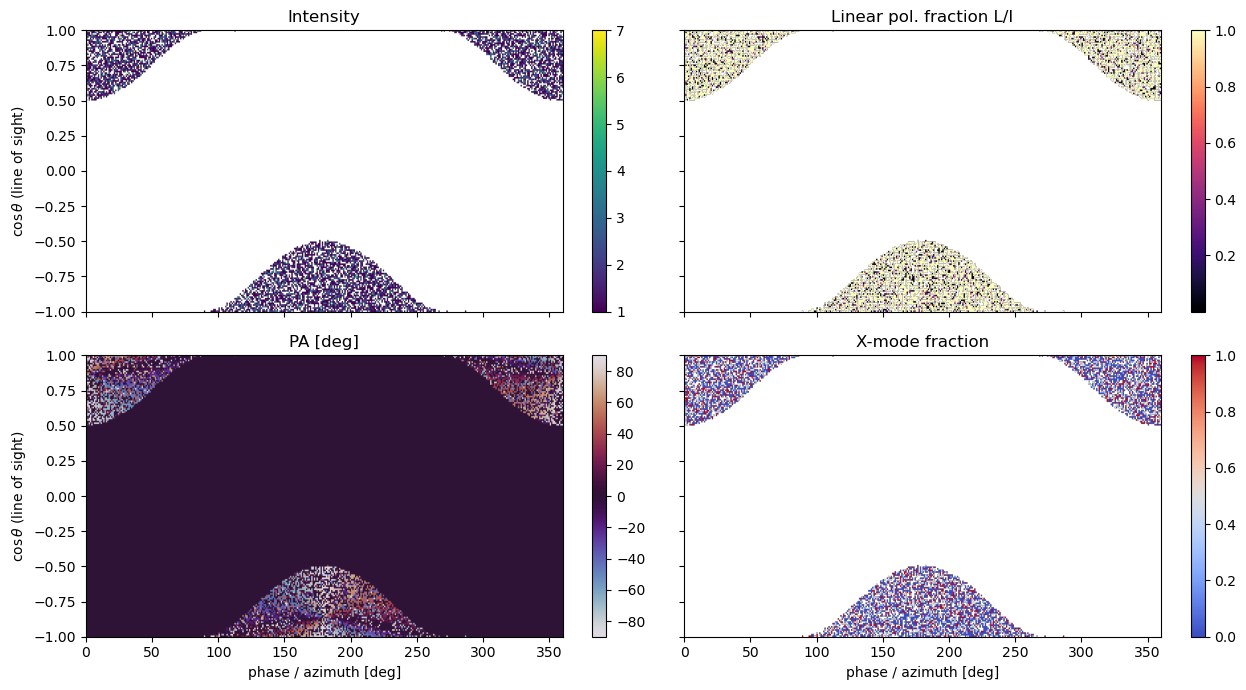

In [53]:
maps = make_maps(res)
L, PA, Xf = plot_maps(maps)

In [54]:
def pulse_profile(mp, zeta_deg):
    """Extract and plot pulse profiles (I, L/I, PA, X-fraction vs. rotation phase) for an observer at a fixed viewing angle by slicing one row of the sky maps.

    Args:
        mp       : dict  -- output dictionary of make_maps() (uses keys I, Q, U, Xf, phie, cthe).
        zeta_deg : float -- observer's viewing angle zeta in degrees, measured from the rotation (z) axis.

    Returns:
        None -- displays a 4-panel matplotlib figure.
    """
    cz  = np.cos(np.deg2rad(zeta_deg))
    row = np.searchsorted(mp['cthe'], cz) - 1
    ph  = np.rad2deg(0.5*(mp['phie'][:-1] + mp['phie'][1:]))
    I   = mp['I'][row];  I_s = np.where(I > 0, I, np.nan)
    Lp  = np.sqrt(mp['Q'][row]**2 + mp['U'][row]**2)/I_s
    PAp = 0.5*np.rad2deg(np.arctan2(mp['U'][row], mp['Q'][row]))
    Xfp = mp['Xf'][row]/I_s

    fig, ax = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
    ax[0].plot(ph, I);   ax[0].set_ylabel('I')
    ax[1].plot(ph, Lp);  ax[1].set_ylabel('L/I'); ax[1].set_ylim(0, 1.05)
    ax[2].plot(ph, PAp, '.'); ax[2].set_ylabel('PA [deg]')
    ax[3].plot(ph, Xfp); ax[3].set_ylabel('X fraction'); ax[3].set_ylim(0, 1.05)
    ax[3].set_xlabel('rotation phase [deg]')
    fig.suptitle(f'Observer at zeta = {zeta_deg} deg (chi = {np.rad2deg(M.chi):.0f} deg)')
    plt.tight_layout(); plt.show()

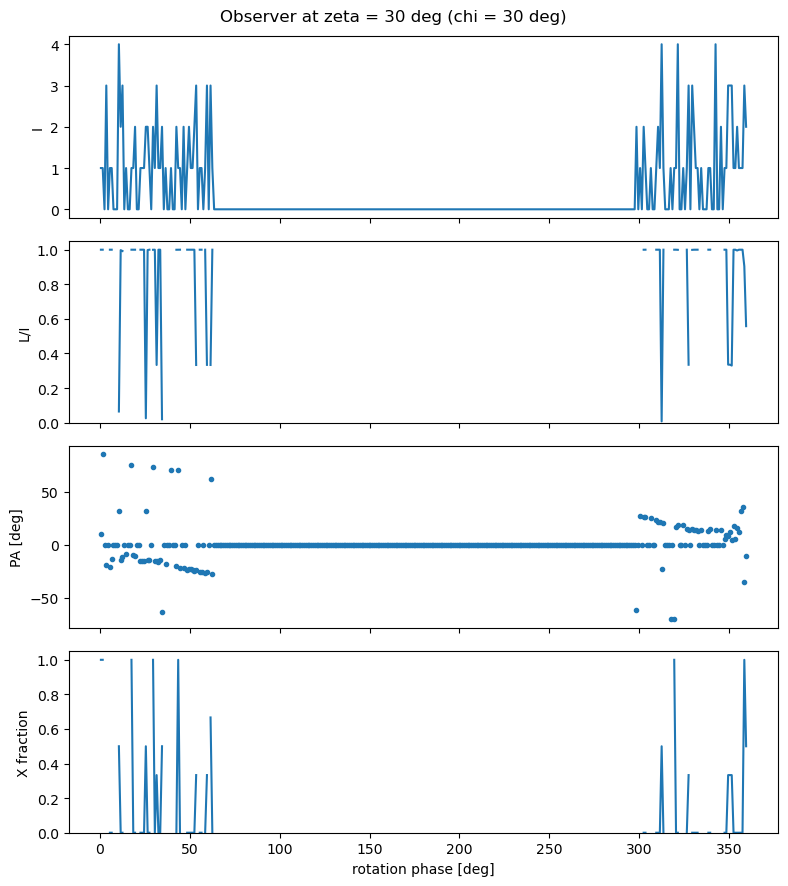

In [55]:
pulse_profile(maps, zeta_deg=30)

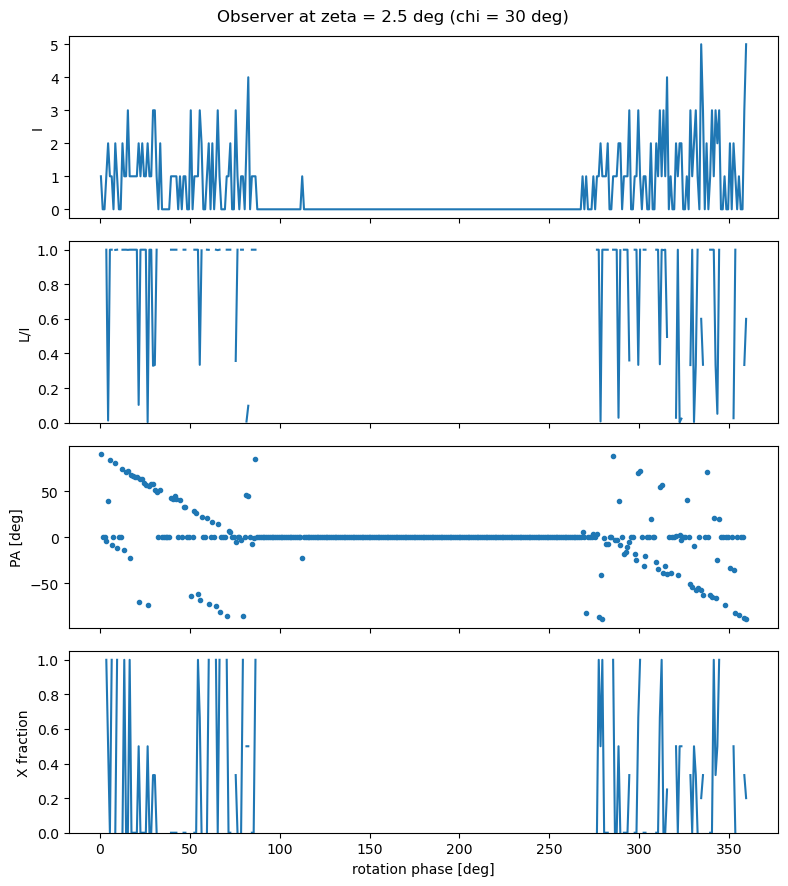

In [56]:
pulse_profile(maps, zeta_deg=2.5)